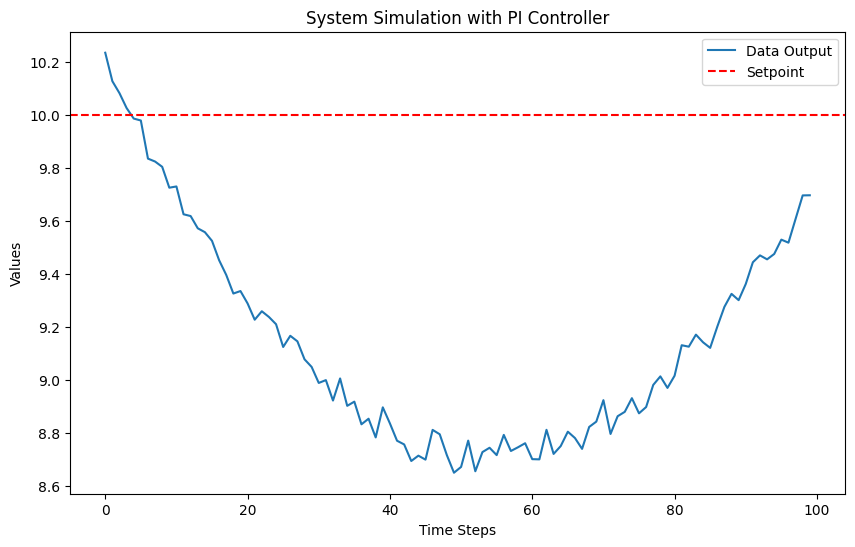

In [6]:
import matplotlib.pyplot as plt
import numpy as np

class PIController:
    def __init__(self, kp, ki):
        self.kp = kp
        self.ki = ki
        self.integral = 0

    def compute(self, error):
        self.integral += error
        return self.kp * error + self.ki * self.integral

# Simulate a system
def simulate_system(setpoint, kp, ki, time_steps):
    controller = PIController(kp, ki)
    data_outputs = []

    for _ in range(time_steps):
        # Simulate the process by adding some random noise
        actual_output = setpoint + (0.5 - 1.0 * _ / time_steps) + 0.1 * (2 * (0.5 - np.random.random()))
        
        # Calculate the error
        error = setpoint - actual_output
        
        # Use the PI controller to get the control output
        control_output = controller.compute(error)
        
        # Update the system (data output) based on the control output
        data_output = actual_output + control_output + 0.05 * (2 * (0.5 - np.random.random()))
        data_outputs.append(data_output)

    return data_outputs

# Setpoint for the system
setpoint = 10.0

# Controller parameters
kp = 0.5
ki = 0.1

# Number of time steps
time_steps = 100

# Simulate the system
data_outputs = simulate_system(setpoint, kp, ki, time_steps)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data_outputs, label='Data Output')
plt.axhline(setpoint, color='r', linestyle='--', label='Setpoint')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.title('System Simulation with PI Controller')
plt.legend()
plt.show()
